<a href="https://colab.research.google.com/github/vedant1008-DE/Machine-Learning-Essentials-Lab-Sem-6/blob/main/4_Linear_%26_Polynomial_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

Question 1 — Load Dataset


In [2]:
# Load dataset
df = sns.load_dataset("mpg")

# Display first 10 rows
print(df.head(10))

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("Columns:", df.columns)

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   
5  15.0          8         429.0       198.0    4341          10.0   
6  14.0          8         454.0       220.0    4354           9.0   
7  14.0          8         440.0       215.0    4312           8.5   
8  14.0          8         455.0       225.0    4425          10.0   
9  15.0          8         390.0       190.0    3850           8.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa         

Question 2 — Data Cleaning


In [3]:
# Check missing values
print(df.isnull().sum())

# Handle missing values
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# Drop rows where mpg is missing
df = df.dropna(subset=['mpg'])

print("Missing values after cleaning:")
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
Missing values after cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


Question 3 — Feature Selection


In [4]:
# Selecting features
X = df[['cylinders','horsepower','weight','displacement']]
y = df['mpg']


Question 4 — Train-Test


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (318, 4)
Testing size: (80, 4)


Question 5 — Linear Regression Model

In [6]:
# Train Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Coefficients
print("Coefficients:", lin_model.coef_)

# Intercept
print("Intercept:", lin_model.intercept_)

Coefficients: [-0.18620277 -0.04028329 -0.00531685 -0.00561704]
Intercept: 45.637601052709044


Question 6 — Evaluate Linear Regression

In [7]:
# Predictions
y_pred = lin_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.119194817737374
MSE: 14.670426917488303
RMSE: 3.830199331299652
R2 Score: 0.7271452992929572


Question 7 — Polynomial Regression

In [8]:
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_poly2, y_train)

train_score2 = model2.score(X_train_poly2, y_train)
test_score2 = model2.score(X_test_poly2, y_test)

print("Degree 2 Train Score:", train_score2)
print("Degree 2 Test Score:", test_score2)

Degree 2 Train Score: 0.7544233511569484
Degree 2 Test Score: 0.778155152872776


Degree 3

In [9]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train_poly3, y_train)

train_score3 = model3.score(X_train_poly3, y_train)
test_score3 = model3.score(X_test_poly3, y_test)

print("Degree 3 Train Score:", train_score3)
print("Degree 3 Test Score:", test_score3)

Degree 3 Train Score: 0.7828273759934901
Degree 3 Test Score: 0.7808241296093856


Question 8 — Learning Curve

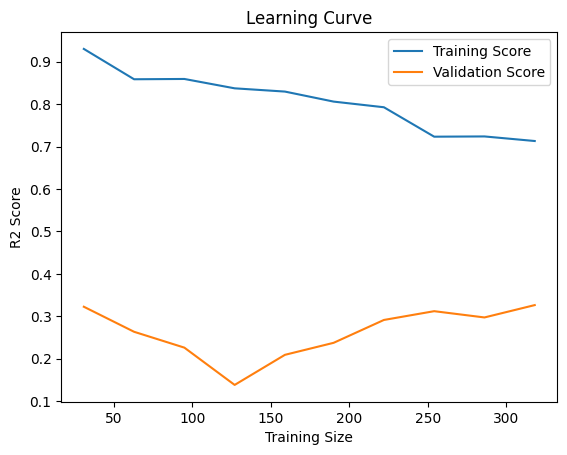

In [10]:
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

Question 9 — Validation Curve

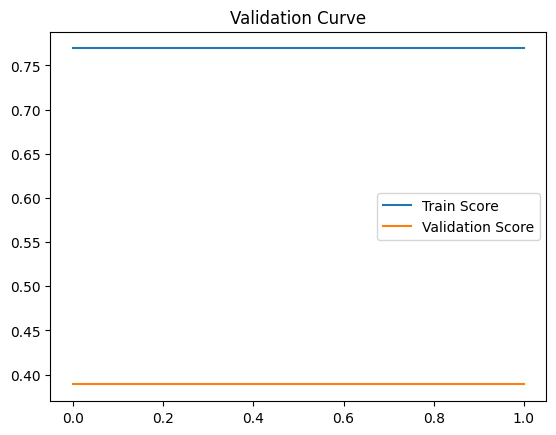

In [11]:
param_range = [1,2,3,4,5]

train_scores, val_scores = validation_curve(
    LinearRegression(),
    PolynomialFeatures().fit_transform(X),
    y,
    param_name="fit_intercept",
    param_range=[True, False],
    cv=5,
    scoring="r2"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.plot(train_mean, label="Train Score")
plt.plot(val_mean, label="Validation Score")
plt.title("Validation Curve")
plt.legend()
plt.show()

Question 10 — Reflection

1. Which model performed better and why?

Polynomial regression performed better because it captures nonlinear relationships between engine features and MPG.

2. What degree caused overfitting?

Higher degrees such as degree 3 or above often cause overfitting where training accuracy becomes very high but testing accuracy drops.

3. How can model generalization be improved?

Model generalization can be improved by:

Using regularization techniques

Increasing training data

Applying cross-validation

Selecting optimal polynomial degree